# ViT Unfolded-Attention CRP Walkthrough

Concept attribution + relevance maximisation on a small ViT (default `vit_small`; `vit_base`, DINOv3 ViT-L also work). Unfolded attention + AlphaBeta(0.5, 0.5) bilinear rule. Three concepts — `HeadConcept`, `EmbeddingDimConcept`, `TokenConcept` — hookable at `q_lrp_probe` / `k_lrp_probe` / `v_lrp_probe` / `proj_drop`.

## Setup

1. `uv sync`.
2. Pick `(base, head, train-ds)` in section 2. Defaults: `vit_small + linear + funny-birds-train-clean`. Datasets auto-download.

| | options |
|---|---|
| **base** | `vit_small` (22 M, default) · `vit_base` (86 M) · `vit_dinov3` (304 M) |
| **head** | `linear` (default) · `attentive` · `block` |
| **train-ds** | `funny-birds-train-clean` (default) · `dsprites` · `colored-mnist-train` · `imagenette-train` · `imagenet-val-hf` |

3. Train probe. vit_small = full-backbone OneCycle finetune:

```bash
uv run python -m experiments.train_probe finetune --from-scratch \
  --base vit_small --head linear --train-ds funny-birds-train-clean \
  --epochs 25 --backbone-lr 5e-4 --head-lr 5e-3 --weight-decay 0.05 \
  --batch-size 64 --accumulate-grad-batches 2 --layerwise-lr-decay 0.7 \
  --scheduler onecycle --randaugment --label-smoothing 0.1 --num-workers 3
```

Output → `data/runs/finetune_vit_small_funny-birds-train-clean/<ts>/best.pt` (section 2 auto-resolves). Frozen-backbone probe instead: `train-probe cache <base> <dataset> --kind <cls|tokens>` then `train-probe train <base> <head> <dataset>`. Missing-ckpt cell prints the exact command.

4. Hardware: vit_small a few GB VRAM. vit_dinov3 wants ≥24 GB.

## Structure
1 setup · 2 config + composite · 3 hookable layers (+3b graph/sanity) · 4 dataset + focal image · 5 FV index · 6 reference samples · 7 conditional cascade · 8 notes

## 1. Setup

In [1]:
# %cd ../..
# %ls
from __future__ import annotations
import warnings
from pathlib import Path

# Walk up from the notebook's location to find the repo root —
# only used to point at <repo>/data/. No sys.path manipulation:
# `experiments` and `crp` are installable packages exposed by
# `uv sync` (project.scripts in pyproject.toml).
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').is_file():
    REPO_ROOT = REPO_ROOT.parent

import torch
import numpy as np
import matplotlib.pyplot as plt

from crp.attribution import CondAttribution
from crp.concepts import HeadConcept, EmbeddingDimConcept, TokenConcept
from zennit_ext import LRPInspectionLayer
from zennit_ext import AttnLRPCombinedComposite
from crp.visualization import FeatureVisualization
from crp.helper import get_layer_names
from crp.image import plot_grid

from experiments.datasets import load as load_dataset
from experiments.models import BASES, HEADS, build_probe
from experiments.viz_unfolded import to_display

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')
print(f'available bases: {list(BASES)}')
print(f'available heads: {list(HEADS)}')

device: cuda
available bases: ['vit_base', 'vit_small', 'vit_dinov3']
available heads: ['linear', 'attentive', 'block']


## 2. Configuration — base × head × train-ds + composite

**Composite** = `AttnLRPCombinedComposite` (recipe: `research/RESEARCH_NOTES.md` Entry 6):

* `alpha=0.5, beta=0.5` — AlphaBeta bilinear rule (Bach 2015 → bilinear). Tight magnitude (~19 OOM tighter than `2y+ε`).
* `layerscale_uniform=True` — uniform rule (Eq. 7) on LayerScale γ: γ absorbs half, branch gets R/2. Stops per-layer ×γ relevance death. DINOv3/Eva only; no-op on vit_small/base.
* `residual_lrp='ratio'` — Otsuki ratio split on residual adds.
* Attention auto-substituted to unfolded form (Eva/timm) — required for concept conditioning.

**Base × head × train-ds** — pick one each. Model rebuilt from the training registry, so swapping head = one variable.

In [ ]:
# === MODEL × TRAIN-DS CHOICE ===
# Pick one (base, head, train_ds). The cell below resolves a checkpoint
# automatically — prefers the most recent OneCycle finetune run under
# `data/runs/finetune_<base>_<train-ds>/<ts>/best.pt`, falls back to
# the legacy probe checkpoint `data/<base>_<head>_probe_<train-ds>.pt`.
# The same backbone receives the same unfolded-attention substitution
# (Eva ↔ EvaAttentionUnfolded, timm ↔ TimmAttentionUnfolded) — concept
# hookable sites (q/k/v_lrp_probe, proj_drop) are uniform across both.

from experiments.train_probe import TRAIN_DATASETS

# Available bases (see `experiments.models.BASES`):
#   'vit_dinov3'  — ViT-L/16 DINOv3 (24 blocks, Eva + LayerScale + RoPE + 4 register tokens)
#   'vit_base'    — ViT-B/16 timm   (12 blocks, no LayerScale)
#   'vit_small'   — ViT-S/16 timm   (12 blocks; our OneCycle-finetuned development substrate)
# Heads: 'linear' | 'attentive' | 'block'.
# Train-ds choices (see TRAIN_DATASETS): 'funny-birds-train-clean',
# 'funny-birds-train-full', 'dsprites', 'colored-mnist-train',
# 'imagenette-train', 'imagenet-val-hf'.
BASE     = 'vit_small'
HEAD     = 'linear'
TRAIN_DS = 'funny-birds-train-clean'

# Resolve the underlying dataset name + kwargs once; used downstream.
DATASET, DATASET_KWARGS = TRAIN_DATASETS[TRAIN_DS]

DATA_ROOT = REPO_ROOT / 'data'

# Checkpoint resolution: latest finetune run wins; probe is the fallback.
import glob as _glob
_finetune_runs = sorted(_glob.glob(str(DATA_ROOT / 'runs' / f'finetune_{BASE}_{TRAIN_DS}' / '*' / 'best.pt')))
_probe_path = DATA_ROOT / f'{BASE}_{HEAD}_probe_{TRAIN_DS}.pt'
if _finetune_runs:
    PROBE_PATH = Path(_finetune_runs[-1])
    print(f'  using OneCycle finetune ckpt: {PROBE_PATH.relative_to(REPO_ROOT)}')
elif _probe_path.is_file():
    PROBE_PATH = _probe_path
    print(f'  using probe ckpt: {PROBE_PATH.relative_to(REPO_ROOT)}')
else:
    # Set explicitly to surface a clean FileNotFoundError in the load cell.
    PROBE_PATH = _probe_path

# Sanity-eval subset size (section 4). Tighter estimate with larger N
# at the cost of more time.
EVAL_SUBSET_SIZE = 200

# Random seed for sample selection.
RANDOM_SEED = 0

# === EXPERIMENT TAG ===
# Optional suffix on the FV cache dir (section 5). Set to a short
# identifier when running a composite variant whose reference
# samples you want kept distinct from the baseline (e.g.
# 'no_ln_canon', 'alpha02beta08'). Empty string → baseline path.
EXPERIMENT_TAG = 'lxt_composite'

print(f'base     : {BASE}')
print(f'head     : {HEAD}')
print(f'train_ds : {TRAIN_DS}  ({DATASET} {DATASET_KWARGS})')
print(f'probe    : {PROBE_PATH}')

  using OneCycle finetune ckpt: data/runs/finetune_vit_small_funny-birds-train-clean/2026-06-03_000556/best.pt
base     : vit_small
head     : linear
train_ds : funny-birds-train-clean  (funny_birds {'split': 'train', 'clean_only': True})
probe    : /home/claude/workspaces/zennit-crp/data/runs/finetune_vit_small_funny-birds-train-clean/2026-06-03_000556/best.pt


In [3]:
# Load the probe checkpoint and rebuild the full model with the same
# `build_probe` registry the training CLI uses. If the probe is
# missing, the cell prints the exact two commands to make it.
if not PROBE_PATH.is_file():
    head_kind = HEADS[HEAD].input_kind
    raise FileNotFoundError(
        f'\nNo checkpoint found for ({BASE}, {HEAD}, {DATASET}).\n\n'
        f'Option A — full OneCycle fine-tune (recommended for vit_small):\n'
        f'  uv run python -m experiments.train_probe finetune \\\n'
        f'    --from-scratch --base {BASE} --dataset {DATASET} \\\n'
        f'    --head {HEAD} --epochs 25 --scheduler onecycle \\\n'
        f'    --backbone-lr 5e-4 --head-lr 5e-3 --llrd 0.7 \\\n'
        f'    --randaugment --label-smoothing 0.1\n\n'
        f'Option B — frozen-backbone probe (DINOv3 style):\n'
        f'  uv run train-probe cache {BASE} {DATASET} --kind {head_kind}\n'
        f'  uv run train-probe train {BASE} {HEAD} {DATASET}\n'
    )
ckpt = torch.load(PROBE_PATH, map_location=DEVICE, weights_only=False)
print(f'probe trained on : {ckpt["dataset"]}'
      f' ({ckpt["num_classes"]} classes)')
_va, _va5 = ckpt.get('val_acc'), ckpt.get('val_acc5')
print(f'val_acc          : {_va:.4f}' if _va is not None else 'val_acc          : (unreported — see sanity-eval below)')
print(f'val_acc5         : {_va5:.4f}' if _va5 is not None else 'val_acc5         : (unreported)')

probe trained on : funny_birds (50 classes)
val_acc          : 0.9738
val_acc5         : 0.9996


In [4]:
from timm.data import resolve_data_config, create_transform
import torch.nn.functional as F
from torchvision.transforms import functional as TF

# Build the full Probe (frozen base + trainable head) via the same
# registry used by the CLI. Backbone is loaded fresh from timm via
# build_probe → Base.__init__; trained head weights come from the ckpt.
model = build_probe(
    base=ckpt['base'], head=ckpt['head'],
    num_classes=ckpt['num_classes'],
    head_kwargs=ckpt.get('head_kwargs', {}),
).eval().to(DEVICE)
model.head.load_state_dict(ckpt['head_state_dict'])
if 'backbone_state_dict' in ckpt:
    # Fine-tuned or externally-trained backbone (e.g. setup_funnybirds_vit_base.py
    # or train_probe finetune_cmd output) overrides whatever the Base class
    # loaded at construction.
    model.backbone.load_state_dict(ckpt['backbone_state_dict'])
    print('  loaded backbone weights from ckpt (pretrained / finetuned)')
for p in model.parameters():
    p.requires_grad_(False)

# Build the eval transform AND the per-batch normalize callable. The
# dataset transform produces unnormalized [0, 1] tensors (display-
# ready, uniform across DataLoader / FeatureVisualization / Lightning
# / raw forward); normalize is applied at the forward boundary so the
# model sees its expected input distribution. This split lets external
# pretrained checkpoints (e.g. visinf vit_base, trained without
# normalize) coexist with timm-default models in the same notebook
# without any denormalize indirection for display.
TRANSFORM_SPEC = ckpt.get('transform_spec', 'timm_default')
if 'transform_spec' not in ckpt:
    print('⚠ ckpt has no `transform_spec` field — falling back to timm_default.')
    if ckpt.get('base') == 'vit_base' and ckpt.get('dataset') == 'funny_birds':
        print('  Your payload looks like the visinf vit_base FunnyBirds checkpoint.')
        print('  Re-run the setup script to refresh the payload with transform_spec:')
        print('    uv run python experiments/scripts/setup_funnybirds_vit_base.py --force')
        print('  Then re-run this cell.')

if TRANSFORM_SPEC == 'timm_default':
    # Resize + crop + ToTensor from timm cfg; mean/std overridden to
    # identity so the timm transform's normalize step is a no-op.
    # The actual normalize stats (read from the registered cfg) ship
    # to the model in a separate callable.
    cfg = resolve_data_config({}, model=model.backbone)
    _resize_cfg = {**cfg, 'mean': (0.0, 0.0, 0.0), 'std': (1.0, 1.0, 1.0)}
    transform = create_transform(**_resize_cfg, is_training=False)
    _mean = torch.tensor(cfg['mean']).view(1, -1, 1, 1).to(DEVICE)
    _std  = torch.tensor(cfg['std']).view(1, -1, 1, 1).to(DEVICE)
    def normalize(x):
        return (x - _mean) / _std
    print(f'transform  : timm_default (resize-only; normalize mean={cfg["mean"]}, std={cfg["std"]})')

elif TRANSFORM_SPEC == 'visinf_funnybirds_vit_base':
    # visinf/funnybirds-framework trains its ViT with `transforms=None`
    # in train.py (only `torchvision.transforms.ToTensor` → [0,1])
    # — NO ImageNet/JFT normalize. Their model wrapper resizes 256→224
    # via `F.interpolate(x, (224, 224))` (defaults to nearest). We use
    # bilinear here for cleaner image resampling — both give 0.98–0.99
    # top-1 on the FunnyBirds test set (within sampling noise of the
    # checkpoint's own `best_acc1=98.0`); the (0.5,0.5,0.5)-normalize +
    # crop_pct=0.9 timm default drops it to ~0.85. The model expects
    # raw [0, 1] inputs → `normalize` is the identity.
    def transform(pil):
        t = TF.to_tensor(pil)[:3]  # drops alpha, keeps [0,1] floats
        t = F.interpolate(t.unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False).squeeze(0)
        return t
    def normalize(x):
        return x
    print('transform  : visinf_funnybirds_vit_base (resize-only; no-normalize)')

else:
    raise ValueError(f'unknown transform_spec {TRANSFORM_SPEC!r} — register a branch in the build-model cell')

_npt = int(getattr(model, 'num_prefix_tokens', 1))
print(f'base       : {ckpt["base"]}')
print(f'head       : {ckpt["head"]} kwargs={ckpt.get("head_kwargs", {})}')
print(f'embed_dim  : {model.embed_dim}')
print(f'num_blocks : {len(model.blocks)}')
print(f'num_heads  : {model.blocks[0].attn.num_heads}')
print(f'head_dim   : {model.blocks[0].attn.head_dim}')
if _npt > 1:
    print(f'num_prefix : {_npt} (1 cls + {_npt - 1} register)')
else:
    print(f'num_prefix : {_npt} (cls only)')

# Read structural dims from the model — concept classes need num_heads
# (HeadConcept / EmbeddingDimConcept slice embed_dim per head).
NUM_HEADS = int(model.blocks[0].attn.num_heads)
HEAD_DIM  = int(model.blocks[0].attn.head_dim)
EMBED_DIM = int(model.embed_dim)
NUM_PREFIX_TOKENS = _npt

# Per-section layer-name discovery uses `get_layer_names` (upstream).
# All hookable LRP-inspection sites are instances of
# `LRPInspectionLayer`; `proj_drop` is a stock `nn.Dropout` and is
# enumerated separately in the sections that need it. See section 3 for
# the discovery printout.

  loaded backbone weights from ckpt (pretrained / finetuned)
⚠ ckpt has no `transform_spec` field — falling back to timm_default.
transform  : timm_default (resize-only; normalize mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
base       : vit_small
head       : linear kwargs={}
embed_dim  : 384
num_blocks : 12
num_heads  : 6
head_dim   : 64
num_prefix : 1 (cls only)


In [5]:
# === COMPOSITE — built explicitly so every rule is editable ===
# A `layer_map` maps module classes → LRP rules (zennit Hooks); `canonizers`
# do the structural forward rewrites. zennit's LayerMapComposite wires them.
# This is exactly what `AttnLRPCombinedComposite` builds internally, spelled
# out so you can swap a rule or drop a canonizer and re-run.
import torch.nn as nn
from zennit.rules import Epsilon, Pass
from zennit.composites import LayerMapComposite
from zennit_ext import (
    # unfolded-attention module types (rule targets)
    BilinearMatmul, SoftmaxAlongLastDim, ScaleByConstant,
    ResidualAdd, UniformAdd, LayerScaleMul,
    # LRP rules as zennit Hooks
    AlphaBetaMatmul, ResidualRatio, Uniform,
    # structural forward-rewrite canonizers
    LayerNormForwardCanonizer, DropoutPassthroughCanonizer,
    TimmBlockResidualCanonizer, EvaBlockResidualCanonizer,
    EvaAttentionSubstitutionCanonizer, TimmAttentionSubstitutionCanonizer,
)

EPSILON     = 1e-6
ALPHA, BETA = 0.5, 0.5

# ─── LAYER MAP — per-module-class LRP rule (zennit Hooks) ───────────
layer_map = [
    # attention internals (exposed by the substitution canonizers below)
    (BilinearMatmul,      AlphaBetaMatmul(alpha=ALPHA, beta=BETA, epsilon=EPSILON)),
    (SoftmaxAlongLastDim, Pass()),   # identity rule (AttnLRP Eq. 9)
    (ScaleByConstant,     Pass()),   # graph constant absorbs no relevance
    # residual / layerscale / pos-embed adds (modules emitted by canonizers)
    (ResidualAdd,         ResidualRatio(epsilon=EPSILON)),  # Otsuki ratio split
    (UniformAdd,          Uniform(factor=2)),               # symmetric residual + x+pos_embed
    (LayerScaleMul,       Uniform(factor=2)),               # gamma absorbs half
    # generic layers
    (nn.Linear,           Epsilon(epsilon=EPSILON)),
    (nn.Conv2d,           Epsilon(epsilon=EPSILON)),
    (nn.GELU,             Pass()),
    (nn.LayerNorm,        Pass()),   # std stop-grad done by the canonizer below
    (nn.Dropout,          Pass()),
    (nn.Identity,         Pass()),
]

# ─── CANONIZERS — structural forward rewrites only ──────────────────
canonizers = [
    LayerNormForwardCanonizer(),
    DropoutPassthroughCanonizer(),
    TimmBlockResidualCanonizer(residual_rule='ratio'),
    EvaBlockResidualCanonizer(residual_rule='ratio', layerscale_uniform=True),
    EvaAttentionSubstitutionCanonizer(block_indices=None),
    TimmAttentionSubstitutionCanonizer(block_indices=None),
]

composite = LayerMapComposite(layer_map=layer_map, canonizers=canonizers)
attribution = CondAttribution(model)
print(f'composite: {len(canonizers)} canonizers, {len(layer_map)} layer_map entries')

composite: 6 canonizers, 12 layer_map entries


### Alternative composite — LXT CP-LRP (reproducibility)

Closest match to LXT (*LRP eXplains Transformers*, Achtibat et al.). Sanity-check vs LXT heatmaps.

| Module | Rule |
|---|---|
| `nn.Conv2d` | Gamma(0.25) |
| `nn.Linear` | Gamma(0.10) |
| `nn.GELU` / `nn.LayerNorm` | identity (`Pass`; LayerNorm stop-grad std) |
| Q/K probes | `StopGradient` → CP-LRP, value-path only |
| context matmul | autograd default (`R_v = weightsᵀ R_y`) |

**CP-LRP**: `QInspectionLayer` / `KInspectionLayer` → `StopGradient` (zero Q/K relevance). Softmax then a graph constant → autograd backward on `context = weights @ v` gives the value attribution. No bilinear rule on `BilinearMatmul`. V probe untouched.

Notes: residual/layerscale rules same as the main composite (LXT table omits them); softmax/scale → `Pass` (harmless under CP-LRP). Activate: set `composite = composite_lxt`, `EXPERIMENT_TAG = 'lxt'`, re-run from section 3.

In [6]:
# === COMPOSITE — LXT paper recipe (CP-LRP attention + gamma-rule linears) ===
from zennit.rules import Gamma
from zennit_ext import (
    SoftmaxAlongLastDim, ScaleByConstant, ResidualAdd, UniformAdd, LayerScaleMul,
    ResidualRatio, Uniform, QInspectionLayer, KInspectionLayer, StopGradient,
    LayerNormForwardCanonizer, DropoutPassthroughCanonizer,
    TimmBlockResidualCanonizer, EvaBlockResidualCanonizer,
    EvaAttentionSubstitutionCanonizer, TimmAttentionSubstitutionCanonizer,
)

LXT_LINEAR_GAMMA = 0.10
LXT_CONV_GAMMA   = 0.25
LXT_EPSILON      = 1e-6

# CP-LRP attention: Q,K probes -> StopGradient (kill those paths). With no
# Q/K gradient the softmax map is a graph constant, so autograd's default
# backward on `weights @ v` delivers R_v = weights^T R_out. NO AlphaBeta on
# BilinearMatmul here (that is the AlphaBeta composite above).
lxt_layer_map = [
    (nn.Linear,           Gamma(gamma=LXT_LINEAR_GAMMA)),
    (nn.Conv2d,           Gamma(gamma=LXT_CONV_GAMMA)),
    (nn.GELU,             Pass()),
    (nn.LayerNorm,        Pass()),
    (nn.Dropout,          Pass()),
    (SoftmaxAlongLastDim, Pass()),
    (ScaleByConstant,     Pass()),
    (ResidualAdd,         ResidualRatio(epsilon=LXT_EPSILON)),
    (UniformAdd,          Uniform(factor=2)),
    (LayerScaleMul,       Uniform(factor=2)),
    (QInspectionLayer,    StopGradient()),  # CP-LRP: kill Q-path relevance
    (KInspectionLayer,    StopGradient()),  # CP-LRP: kill K-path relevance
    (nn.Identity,         Pass()),          # incl. VInspectionLayer (untouched)
]

lxt_canonizers = [
    LayerNormForwardCanonizer(),
    DropoutPassthroughCanonizer(),
    TimmBlockResidualCanonizer(residual_rule='ratio'),
    EvaBlockResidualCanonizer(residual_rule='ratio', layerscale_uniform=True),
    EvaAttentionSubstitutionCanonizer(block_indices=None),
    TimmAttentionSubstitutionCanonizer(block_indices=None),
]

composite_lxt = LayerMapComposite(layer_map=lxt_layer_map, canonizers=lxt_canonizers)
print(f'composite_lxt: {len(lxt_canonizers)} canonizers, {len(lxt_layer_map)} layer_map entries')

# To evaluate LXT side-by-side: composite = composite_lxt ; EXPERIMENT_TAG = "lxt"

composite_lxt: 6 canonizers, 13 layer_map entries


## 3. Hookable layers

Unfolded attention exposes 3 `LRPInspectionLayer` sites/block — `q_lrp_probe` / `k_lrp_probe` / `v_lrp_probe` (post qkv-split, pre head-reshape). All carry `(B, N, embed_dim)`, same as `proj_drop`. Concepts act on that shape:

| Concept | Selects | Sites |
|---|---|---|
| `HeadConcept(num_heads)` | one head's embed_dim slice (sums head_dim) | q/k/v_lrp_probe, proj_drop |
| `EmbeddingDimConcept(num_heads)` | one embed_dim index | same |
| `TokenConcept()` | one token position | proj_drop |

Optional `token_filter=slice(...)` restricts tokens (`slice(num_prefix_tokens, None)` = spatial only; default = all).
List sites: `get_layer_names(model, [LRPInspectionLayer])`; `proj_drop` / `context` via `model.named_modules()`.

In [7]:
# Enumerate all LRPInspectionLayer sites in the model. Three per
# block: q_lrp_probe / k_lrp_probe / v_lrp_probe.
with composite.context(model):
    probe_layer_names = get_layer_names(model, [LRPInspectionLayer])
print(f'LRPInspectionLayer sites: {len(probe_layer_names)} total')
for n in probe_layer_names[:6]:
    print(f'  {n}')
if len(probe_layer_names) > 6:
    print(f'  ... ({len(probe_layer_names) - 6} more)')

print()
print(f'NUM_HEADS={NUM_HEADS}, HEAD_DIM={HEAD_DIM}, EMBED_DIM={EMBED_DIM}, NUM_PREFIX_TOKENS={NUM_PREFIX_TOKENS}')

LRPInspectionLayer sites: 36 total
  backbone.blocks.0.attn.q_lrp_probe
  backbone.blocks.0.attn.k_lrp_probe
  backbone.blocks.0.attn.v_lrp_probe
  backbone.blocks.1.attn.q_lrp_probe
  backbone.blocks.1.attn.k_lrp_probe
  backbone.blocks.1.attn.v_lrp_probe
  ... (30 more)

NUM_HEADS=6, HEAD_DIM=64, EMBED_DIM=384, NUM_PREFIX_TOKENS=1


### Single-block computation graph

Render one unfolded attention block as a graph. Composite context swaps stock attention → `EvaAttentionUnfolded` / `TimmAttentionUnfolded`, exposing every op (`qkv`, `q/k/v_lrp_probe`, `scale_q`, `qk_scores`, `softmax`, `context`, `proj`, …) as a named child. Names = the strings for `record_layer=[...]` / condition dicts.
Via [`torchview`](https://github.com/mert-kurttutan/torchview) + Graphviz (SVG); no graphviz → prints the submodule tree. Install: `apt install graphviz` / `brew install graphviz`.

In [8]:
BLOCK_TO_VIZ = 0  # block index to render — same graph for all blocks

try:
    from torchview import draw_graph
    _can_torchview = True
except ImportError:
    print('torchview not installed; run `uv pip install torchview` and re-run.')
    _can_torchview = False

if _can_torchview:
    # Substitute the attention with its unfolded variant via the composite
    # context — that's the graph we actually run attribution against.
    with composite.context(model) as modified:
        block = modified.backbone.blocks[BLOCK_TO_VIZ]
        # Probe the right token-sequence shape from the model.
        _N = _npt + int(getattr(model, 'num_patches', 196))
        _x = torch.randn(1, _N, model.embed_dim, device=DEVICE)
        try:
            g = draw_graph(
                block, input_data=_x,
                depth=3, expand_nested=True,
                graph_name=f'block_{BLOCK_TO_VIZ}',
                hide_module_functions=False,
            )
            # Render to in-memory SVG. Requires system `graphviz` (the
            # `dot` binary). On a missing binary the call raises;
            # we catch and fall back to a structural print below.
            from IPython.display import display, SVG
            svg_str = g.visual_graph.pipe(format='svg').decode('utf-8')
            display(SVG(svg_str))
        except Exception as e:
            print(f'graphviz render failed ({type(e).__name__}: {e!s}).')
            print(f'Falling back to named-submodule tree of block {BLOCK_TO_VIZ}:')
            print('  ' + '\n  '.join(
                f'{name}: {type(m).__name__}'
                for name, m in block.named_modules() if name
            ))

graphviz render failed (ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH).
Falling back to named-submodule tree of block 0:
  norm1: LayerNorm
  attn: TimmAttentionUnfolded
  attn.qkv: Linear
  attn.q_norm: Identity
  attn.k_norm: Identity
  attn.attn_drop: Dropout
  attn.norm: Identity
  attn.proj: Linear
  attn.proj_drop: Dropout
  attn.split: ChunkAlongLastDim
  attn.scale_q: ScaleByConstant
  attn.qk_scores: BilinearMatmul
  attn.add_mask: AddBias
  attn.softmax: SoftmaxAlongLastDim
  attn.context: BilinearMatmul
  attn.reshape: ReshapeMergeHeads
  attn.q_lrp_probe: QInspectionLayer
  attn.k_lrp_probe: KInspectionLayer
  attn.v_lrp_probe: VInspectionLayer
  ls1: Identity
  drop_path1: Identity
  norm2: LayerNorm
  mlp: Mlp
  mlp.fc1: Linear
  mlp.act: GELU
  mlp.drop1: Dropout
  mlp.norm: Identity
  mlp.fc2: Linear
  mlp.drop2: Dropout
  ls2: Identity
  drop_path2: Identity
  _lrp_res1: ResidualAdd
  _lrp_res2: Res

#### Canonized-block sanity check

torchview dead-ends = layout artifact, not real. Ground truth:
1. **Forward parity** — unfolded block output == stock block output (fp32 noise).
2. **No dead ends** — every named submodule output has nonzero grad w.r.t. block output. Zero/`None` grad = real bug.

In [10]:
import torch as _torch_chk

with _torch_chk.no_grad():
    _stock_block = model.backbone.blocks[BLOCK_TO_VIZ]
    _x_stock = _torch_chk.randn(1, _N, model.embed_dim, device=DEVICE)
    _y_stock = _stock_block(_x_stock)

with composite.context(model) as _modified_for_check:
    _sub_block = _modified_for_check.backbone.blocks[BLOCK_TO_VIZ]

    # 1. Forward parity
    with _torch_chk.no_grad():
        _y_sub = _sub_block(_x_stock)
    _max_diff = (_y_sub - _y_stock).abs().max().item()
    _stock_sum, _sub_sum = _y_stock.sum().item(), _y_sub.sum().item()
    _ok_fwd = _max_diff < 1e-2 * max(abs(_stock_sum), 1.0)
    print(f'Forward parity: stock sum={_stock_sum:.4f}, substituted sum={_sub_sum:.4f}')
    print(f'  max element-wise diff = {_max_diff:.3e}  → {"OK" if _ok_fwd else "⚠ MISMATCH"}')

    # 2. Dead-end check — register forward hooks on every named submodule
    _captured = {}
    _handles = []
    for _name, _m in _sub_block.named_modules():
        if not _name:
            continue
        def _hook(_mod, _inp, _out, __n=_name):
            if isinstance(_out, _torch_chk.Tensor) and _out.requires_grad:
                _out.retain_grad()
                _captured[__n] = _out
        _handles.append(_m.register_forward_hook(_hook))
    try:
        _x_grad = _torch_chk.randn(1, _N, model.embed_dim, device=DEVICE, requires_grad=True)
        _y_grad = _sub_block(_x_grad)
        _y_grad.sum().backward()
    finally:
        for _h in _handles:
            _h.remove()
    _dead = [
        n for n, t in _captured.items()
        if t.grad is None or t.grad.abs().sum().item() == 0
    ]
    print(f'\nDead-end check on {len(_captured)} hookable submodules:')
    if _dead:
        print(f'  ⚠ {len(_dead)} dead end(s) — these submodules do NOT contribute to the block output:')
        for n in _dead:
            print(f'    {n}')
    else:
        print(f'  ✓ all {len(_captured)} submodules contribute to the block output')

Forward parity: stock sum=840.2164, substituted sum=840.1908
  max element-wise diff = 5.732e-03  → OK

Dead-end check on 32 hookable submodules:
  ✓ all 32 submodules contribute to the block output


## 4. Load dataset + focal image

`load(name, ...)` dispatcher (`experiments/datasets/`) — auto download/extract. Focal image = first correctly-classified sample; attribution targets its predicted class.

In [11]:
# Build the dataset variants used downstream. For FunnyBirds we expose
# three named handles so it's easy to switch what the FV cache (sec 9)
# and the cascade (sec 11) operate on:
#
#   dataset_test          : held-out test split (500 imgs, 0% ablations)
#   dataset_train_clean   : train filtered to intact birds (~29k imgs)
#   dataset_train_ablated : full train, includes part-ablations (~50k,
#                           ~41% have one or more body parts replaced
#                           with 'placeholder' renders).
#
# Downstream cells read `dataset` — change the assignment below to
# switch the FV indexing pool. The sanity-eval cell uses
# `dataset_eval` independently (always the clean test split for
# FunnyBirds — matches the advertised accuracy figure).
if DATASET == 'funny_birds':
    dataset_test          = load_dataset('funny_birds', transform=transform, split='test')
    dataset_train_clean   = load_dataset('funny_birds', transform=transform, split='train', clean_only=True)
    dataset_train_ablated = load_dataset('funny_birds', transform=transform, split='train', clean_only=False)
    dataset_eval = dataset_test
    # Default: ablated train — gives the FV cache access to part-
    # ablation samples, so the resulting concept references reveal
    # whether any head/channel fires specifically on missing-part
    # renders. Switch to `dataset_train_clean` for a baseline FV that
    # mirrors the test distribution.
    dataset = dataset_train_ablated
    print(f'  dataset_test          : {len(dataset_test):>6d} imgs')
    print(f'  dataset_train_clean   : {len(dataset_train_clean):>6d} imgs')
    print(f'  dataset_train_ablated : {len(dataset_train_ablated):>6d} imgs')
else:
    _load_kwargs = {
        'dsprites':        dict(target='shape'),
        'imagenette':      dict(split='val'),
        'imagenet_val_hf': dict(),
    }[DATASET]
    dataset_eval = dataset = load_dataset(DATASET, transform=transform, **_load_kwargs)
print(f'downstream `dataset`      : {len(dataset):>6d} imgs')
print(f'sanity-eval `dataset_eval`: {len(dataset_eval):>6d} imgs')

  FunnyBirds test: 500 images, 50 classes
  FunnyBirds train: clean_only filter kept 29330/50000 samples (58.7%); ablated samples dropped.
  FunnyBirds train: 29330 images, 50 classes
  FunnyBirds train: 50000 images, 50 classes
  dataset_test          :    500 imgs
  dataset_train_clean   :  29330 imgs
  dataset_train_ablated :  50000 imgs
downstream `dataset`      :  50000 imgs
sanity-eval `dataset_eval`:    500 imgs


### Sanity-eval: does the model classify this dataset?

Run the model on a slice of `dataset_eval` (FunnyBirds held-out test, 0% ablations). Near-chance = checkpoint loaded wrong (head shape / missing backbone / base-dataset mismatch / transform mismatch). Bump `EVAL_SUBSET_SIZE`.

In [12]:
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

n_eval = min(EVAL_SUBSET_SIZE, len(dataset_eval))
_loader = DataLoader(
    Subset(dataset_eval, list(range(n_eval))),
    batch_size=32, shuffle=False, num_workers=2,
)
_correct = _total = 0
with torch.no_grad():
    for _x, _y in tqdm(_loader, desc='sanity-eval', unit='batch'):
        # Dataset yields unnormalized tensors; normalize at the forward
        # boundary.
        _logits = model(normalize(_x.to(DEVICE)))
        _correct += (_logits.argmax(-1).cpu() == _y).sum().item()
        _total   += _y.numel()
print(f'Sanity-eval top-1 over {_total} samples of dataset_eval: {_correct/_total:.4f}')
if 'val_acc' in ckpt and ckpt['val_acc'] is not None:
    print(f'  (advertised val_acc in payload: {ckpt["val_acc"]:.4f})')

sanity-eval:   0%|          | 0/7 [00:00<?, ?batch/s]

Sanity-eval top-1 over 200 samples of dataset_eval: 0.9800
  (advertised val_acc in payload: 0.9738)


### Pick the focal image

focal image: dataset index 100, class 0


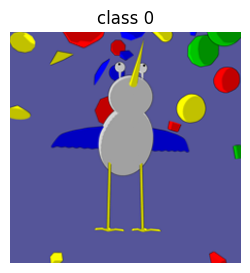

In [19]:
# `focal_image` holds the UNNORMALIZED [0, 1] tensor — display-ready,
# safe to pass to viz_unfolded funcs (which `preprocess_fn=normalize`).
# Model forwards inside this cell normalize at the boundary.
rng = np.random.default_rng(RANDOM_SEED)
stride = max(1, len(dataset) // 30)
focal_image = focal_class = focal_index = None
for i in range(100, len(dataset), stride):
    x_, y_ = dataset[i]
    x_dev = x_.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(normalize(x_dev)).argmax(-1).item()
    if pred == int(y_):
        focal_image = x_dev.detach().requires_grad_(True)
        focal_class = pred
        focal_index = i
        break
if focal_image is None:
    raise RuntimeError(
        f'No correctly-classified sample found in first {len(dataset)//stride} '
        f'strided samples — probe accuracy may be too low. Re-train it with '
        f'more epochs or check dataset compatibility.'
    )

print(f'focal image: dataset index {focal_index}, class {focal_class}')
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(to_display(focal_image)); ax.axis('off')
ax.set_title(f'class {focal_class}')
plt.show()

### Plain attribution (no concept conditioning) for reference

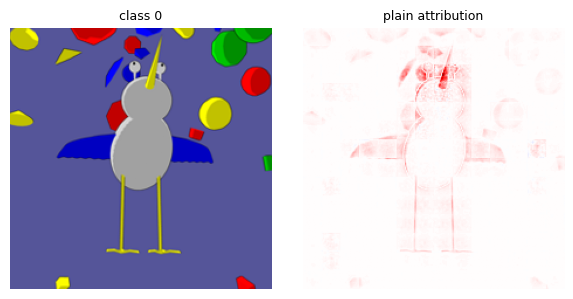

In [20]:
# Attribution runs on the NORMALIZED tensor — that's what the model
# expects internally. The display tensor stays unnormalized.
x_run = normalize(focal_image).detach().clone().requires_grad_(True)
res = attribution(x_run, [{'y': [focal_class]}], composite_lxt)
hm = res.heatmap[0].detach().cpu().numpy()
if hm.ndim == 3 and hm.shape[0] == 3:
    hm = hm.sum(axis=0)
fig, (ax_img, ax_hm) = plt.subplots(1, 2, figsize=(6, 3))
ax_img.imshow(to_display(focal_image)); ax_img.axis('off')
ax_img.set_title(f'class {focal_class}', fontsize=9)
vmax = abs(hm).max() or 1.0
ax_hm.imshow(hm, cmap='seismic', vmin=-vmax, vmax=vmax); ax_hm.axis('off')
ax_hm.set_title('plain attribution', fontsize=9)
plt.tight_layout(); plt.show()

## 5. Build FV index

3 concepts × target sites (probes + `proj_drop`). FV indexes each concept id's relevance over the dataset, caches top-N images.

Cache (per `(base, head, train-ds)`, parallel-safe):

```
data/fv_cache/<base>_<head>_<train-ds>/<tag>/
    RelMax_*/   ActMax_*/    # top-N indices
```

Re-run safe: existing `<tag>/RelMax_*/*_data.npy` → skip indexing, rebind to disk. Force rebuild: delete the tag folder.

In [ ]:
# Cache root keyed by (base, head, dataset) — switching BASE/HEAD/DATASET
# in section 2 routes to a different cache, so combinations don't
# collide. Independent caches are also safe across parallel notebook
# kernels (each writes only into its own path).
# An optional EXPERIMENT_TAG (set in section 2) becomes a suffix on
# the cache dir so different composite variants can index in
# parallel without overwriting each other.
_suffix = f'_{EXPERIMENT_TAG}' if EXPERIMENT_TAG else ''
FV_CACHE_DIR = REPO_ROOT / 'data' / 'fv_cache' / f'{BASE}_{HEAD}_{TRAIN_DS}{_suffix}'
FV_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f'cache dir: {FV_CACHE_DIR.relative_to(REPO_ROOT)}')

# Discover all 3D inspection sites: the LRPInspectionLayer probes
# (q/k/v_lrp_probe per block) plus proj_drop (per block).
with composite_lxt.context(model):
    probe_layer_names = get_layer_names(model, [LRPInspectionLayer])
proj_drop_layer_names = [
    f'backbone.blocks.{i}.attn.proj_drop' for i in range(len(model.blocks))
]

# Quick defaults: index a single concept × single layer for each
# concept type. Comment / uncomment / extend per your analysis. Adding
# more layers per fv_specs entry just grows the layer_map of one
# FeatureVisualization — same one forward+backward pass per image.
_LAST_BLOCK = len(model.blocks) - 1
_LAST_PROJ  = f'backbone.blocks.{_LAST_BLOCK}.attn.proj_drop'
_LAST_QPROBE = f'backbone.blocks.{_LAST_BLOCK}.attn.q_lrp_probe'
_LAST_KPROBE = f'backbone.blocks.{_LAST_BLOCK}.attn.k_lrp_probe'
_LAST_VPROBE = f'backbone.blocks.{_LAST_BLOCK}.attn.v_lrp_probe'

fv_specs = [
    # (cache-tag, concept-instance, list-of-target-layers)
    ('head_at_proj',     HeadConcept(num_heads=NUM_HEADS),         [_LAST_PROJ]),
    ('head_at_qprobe',   HeadConcept(num_heads=NUM_HEADS),         [_LAST_QPROBE]),
    ('head_at_kprobe',   HeadConcept(num_heads=NUM_HEADS),         [_LAST_KPROBE]),
    ('head_at_vprobe',   HeadConcept(num_heads=NUM_HEADS),         [_LAST_VPROBE]),
    ('embdim_at_proj',   EmbeddingDimConcept(num_heads=NUM_HEADS), [_LAST_PROJ]),
    ('token_at_proj',    TokenConcept(),                            [_LAST_PROJ]),
    # ── Cascade-style: HeadConcept across multiple depths ────────────
    # ('head_cascade', HeadConcept(num_heads=NUM_HEADS),
    #     [f'backbone.blocks.{i}.attn.proj_drop' for i in [_LAST_BLOCK, _LAST_BLOCK*3//4, _LAST_BLOCK//2, _LAST_BLOCK//4, 0]]),
]

from tqdm.auto import tqdm

# Outer bar tracks fv_specs entries; the inner fv.run() shows its own
# per-image progress bar from upstream crp/visualization.py.
fv_results = {}
_outer = tqdm(fv_specs, desc='FV specs', unit='spec')
for tag, concept, layers in _outer:
    _outer.set_postfix_str(tag)
    cache_path = FV_CACHE_DIR / tag
    fv = FeatureVisualization(
        attribution=attribution, dataset=dataset,
        layer_map={layer: concept for layer in layers},
        preprocess_fn=normalize,
        path=str(cache_path), device=DEVICE,
    )
    has_index = cache_path.is_dir() and all(
        list(cache_path.rglob(f'{layer}_data.npy')) for layer in layers
    )
    if has_index:
        tqdm.write(f'skip {tag}: index present at {cache_path}')
    else:
        tqdm.write(f'index {tag} → {len(layers)} layer(s) over {len(dataset)} imgs ...')
        fv.run(composite_lxt, 0, len(dataset), batch_size=128, checkpoint=999)
    fv_results[tag] = (fv, concept, layers)
print('FV indexing complete')

cache dir: data/fv_cache/vit_small_linear_funny-birds-train-clean


FV specs:   0%|          | 0/6 [00:00<?, ?spec/s]

index head_at_proj → 1 layer(s) over 50000 imgs ...
Running Analysis...


OutOfMemoryError: CUDA out of memory. Tried to allocate 228.00 MiB. GPU 0 has a total capacity of 44.42 GiB of which 7.81 MiB is free. Including non-PyTorch memory, this process has 44.41 GiB memory in use. Of the allocated memory 42.48 GiB is allocated by PyTorch, and 1.61 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 6. Reference samples per concept × site

Top-K concept ids from FV scores → fetch reference samples → `plot_grid`. One cell per concept × site.

In [ ]:
# HeadConcept @ proj_drop — what does each head's contribution to the
# attention output look like?
fv, concept, layers = fv_results['head_at_proj']
layer = layers[0]
head_ids = list(range(NUM_HEADS))   # show all heads
ref = fv.get_max_reference(head_ids, layer, 'relevance', (0, 8), composite=composite)
print(f'HeadConcept at {layer} — top-8 reference samples per head ({NUM_HEADS} heads)')
_ = plot_grid(ref, figsize=(12, 3 * NUM_HEADS), padding=False)

In [ ]:
# Same HeadConcept, hooked at q_lrp_probe — ‘which input pixels',
# 'populated this head’s query subspace?'
fv, concept, layers = fv_results['head_at_qprobe']
layer = layers[0]
ref = fv.get_max_reference(list(range(NUM_HEADS)), layer, 'relevance', (0, 8), composite=composite)
print(f'HeadConcept at {layer}')
_ = plot_grid(ref, figsize=(12, 3 * NUM_HEADS), padding=False)

In [ ]:
# Same idea for v_lrp_probe — value subspace.
fv, concept, layers = fv_results['head_at_vprobe']
layer = layers[0]
ref = fv.get_max_reference(list(range(NUM_HEADS)), layer, 'relevance', (0, 8), composite=composite)
print(f'HeadConcept at {layer}')
_ = plot_grid(ref, figsize=(12, 3 * NUM_HEADS), padding=False)

In [ ]:
# EmbeddingDimConcept at proj_drop — top-K dims.
fv, concept, layers = fv_results['embdim_at_proj']
layer = layers[0]
TOP_K = 8
# Pick the top-K dims by abs-sum of relevance from FV's pre-computed
# top-N table. (FV already sorts ids by relevance internally; here we
# just sample the first TOP_K dim ids 0..TOP_K-1 for a deterministic demo.)
dim_ids = list(range(TOP_K))
ref = fv.get_max_reference(dim_ids, layer, 'relevance', (0, 8), composite=composite)
print(f'EmbeddingDimConcept at {layer} — dims {dim_ids}')
_ = plot_grid(ref, figsize=(12, 3 * TOP_K), padding=False)

In [ ]:
# TokenConcept at proj_drop — per-token-position attribution.
# Default token_filter = slice(None) → ids index into the FULL token
# axis. For DINOv3 (5 prefix tokens): id 0 = cls, ids 1..4 = register,
# ids 5+ = patches. For vit_base (1 prefix): id 0 = cls, ids 1+ = patches.
fv, concept, layers = fv_results['token_at_proj']
layer = layers[0]
# Show the prefix tokens (cls + any register tokens).
token_ids = list(range(NUM_PREFIX_TOKENS))
ref = fv.get_max_reference(token_ids, layer, 'relevance', (0, 8), composite=composite)
labels = ['cls'] + [f'reg{i}' for i in range(NUM_PREFIX_TOKENS - 1)]
print(f'TokenConcept at {layer} — prefix-token positions: {labels}')
_ = plot_grid(ref, figsize=(12, 3 * NUM_PREFIX_TOKENS), padding=False)

## 7. Conditional propagation cascade

Walk attention layers deep → shallow. Per layer: condition on the top-K relevant heads, accumulate conditioning, render one heatmap row. Loop is inline — tinker freely.

In [ ]:
import matplotlib.pyplot as plt

# Cascade depths: deep → shallow. Use proj_drop sites so we get the
# attention block's full output.
_L = _LAST_BLOCK
cascade_layer_names = [
    f'backbone.blocks.{i}.attn.proj_drop'
    for i in [_L, _L * 3 // 4, _L // 2, _L // 4, 0]
]

cascade_concept = HeadConcept(num_heads=NUM_HEADS)
TOP_K = 4

# Focal image (already picked above) → re-run forward + per-layer
# conditional attribution. Built the normalize fn in the build-model
# cell.
x_focal = normalize(focal_image).detach().clone().requires_grad_(True)

fig, axes = plt.subplots(
    len(cascade_layer_names), TOP_K + 1,
    figsize=(2.5 * (TOP_K + 1), 2.5 * len(cascade_layer_names)),
    squeeze=False,
)
extra_conditions = {}   # accumulates as we walk deep → shallow
selected = {}
for row, layer in enumerate(cascade_layer_names):
    # Per-head relevance scores under the cumulative conditioning.
    cond = {'y': [focal_class], **extra_conditions}
    res = attribution(
        x_focal, [cond], composite,
        mask_map=cascade_concept.mask, record_layer=[layer],
        exclude_parallel=False,
    )
    rel = res.relevances[layer]   # (1, N, embed_dim)
    head_scores = cascade_concept.attribute(rel, abs_norm=False)[0]   # (NUM_HEADS,)
    top_heads = torch.argsort(head_scores.abs(), descending=True)[:TOP_K].tolist()
    selected[layer] = top_heads

    # Show focal image on the left, then one heatmap per top head.
    axes[row, 0].imshow(to_display(focal_image)); axes[row, 0].axis('off')
    axes[row, 0].set_title(layer.replace('backbone.', ''), fontsize=7, loc='left', family='monospace')
    for col, h in enumerate(top_heads, start=1):
        x_h = normalize(focal_image).detach().clone().requires_grad_(True)
        res_h = attribution(
            x_h, [{layer: [h], 'y': [focal_class], **extra_conditions}],
            composite, mask_map=cascade_concept.mask,
            exclude_parallel=False,
        )
        hm = res_h.heatmap[0].detach().cpu().numpy()
        if hm.ndim == 3:
            hm = hm.sum(axis=0)
        vmax = abs(hm).max() or 1.0
        axes[row, col].imshow(hm, cmap='seismic', vmin=-vmax, vmax=vmax)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'H{h}', fontsize=7)

    # Add this layer's selection to extra_conditions for the next (shallower) layer.
    extra_conditions[layer] = top_heads

fig.suptitle(f'Cascade: HeadConcept top-{TOP_K} heads per layer (deep → shallow)', fontsize=10)
plt.tight_layout()
plt.show()

print('selected heads per layer (deep → shallow):')
for layer in cascade_layer_names:
    print(f'  {layer}  →  H{selected[layer]}')

## 8. Notes

* **Magnitude.** AlphaBeta(0.5, 0.5) → input `|R|_max` ~O(10²), conservation within a few × the target logit (vs ~10²² under `2y+ε`; `research/RESEARCH_NOTES.md` Entry 6).
* **One concept, many sites.** Same `HeadConcept` / `EmbeddingDimConcept` instance hooks at `q/k/v_lrp_probe` or `proj_drop` — all `(B, N, embed_dim)`.
* **Token masking.** `token_filter=slice(NUM_PREFIX_TOKENS, None)` = spatial only; `slice(0, NUM_PREFIX_TOKENS)` = prefix only.
* **Skip the last block for prefix-token attribution.** Head reads cls only → register-token relevance at last-block `proj_drop` is exactly 0. Use an earlier block.
* **FV scope.** Default = whole dataset. Fast dev: `len(dataset)` → small int in `fv.run(...)`. Cache reused on re-run.
* **No `AttnWeightConcept`.** Softmax weights lack fixed per-neuron semantics → reference retrieval uninformative. Still hookable for raw attention maps: `record_layer=['backbone.blocks.{i}.attn.softmax']`.